# DefectVision — Notebook 09
## Final Comprehensive Evaluation

This notebook performs **evaluation only** on the validation-selected final model from Notebook 08.

Final selected model:
- MS-Residual U-Net
- Weighted BCE + Dice
- Best validation epoch: 8
- Test Dice: 0.3753
- Test IoU: 0.2758
- Test Precision: 0.3484
- Test Recall: 0.6988

No training is performed.


In [1]:

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE=torch.device("cpu")

ROOT=Path.cwd().resolve().parent
DATA=ROOT/"data"/"raw"/"MVTecAD-SEG"
IMG=DATA/"imgs"; ANN=DATA/"annotations"

CHECKPOINT=ROOT/"models"/"checkpoints"/"model08_no_boundary_best.pth"
OUT=ROOT/"results"/"final_evaluation"
FIG=OUT/"figures"
OUT.mkdir(parents=True,exist_ok=True); FIG.mkdir(parents=True,exist_ok=True)

SIZE=256
BATCH=4

print("Device:",DEVICE)
print("Checkpoint:",CHECKPOINT)
print("Exists:",CHECKPOINT.exists())
assert CHECKPOINT.exists(), "Final checkpoint not found."


Device: cpu
Checkpoint: C:\Documents\DefectVision\models\checkpoints\model08_no_boundary_best.pth
Exists: True


In [2]:

class DefectDataset(Dataset):
    def __init__(self,split):
        self.paths=sorted((IMG/split).glob("*.png"))
        self.mask_dir=ANN/split
        self.mean=torch.tensor([.485,.456,.406]).view(3,1,1)
        self.std=torch.tensor([.229,.224,.225]).view(3,1,1)
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        p=self.paths[i]
        im=Image.open(p).convert("RGB").resize((SIZE,SIZE),Image.Resampling.BILINEAR)
        ma=Image.open(self.mask_dir/p.name).convert("L").resize((SIZE,SIZE),Image.Resampling.NEAREST)
        im=torch.from_numpy(np.asarray(im,dtype=np.float32)/255).permute(2,0,1).contiguous()
        ma=torch.from_numpy((np.asarray(ma)>0).astype(np.float32)).unsqueeze(0)
        im=(im-self.mean)/self.std
        return im,ma,p.stem

test_dataset=DefectDataset("test")
test_loader=DataLoader(test_dataset,batch_size=BATCH,shuffle=False,num_workers=0)

print("Test images:",len(test_dataset))
print("Test batches:",len(test_loader))


Test images: 253
Test batches: 64


In [3]:

class RB(nn.Module):
    def __init__(self,a,b):
        super().__init__()
        g=min(8,b)
        self.c1=nn.Conv2d(a,b,3,padding=1,bias=False)
        self.n1=nn.GroupNorm(g,b)
        self.c2=nn.Conv2d(b,b,3,padding=1,bias=False)
        self.n2=nn.GroupNorm(g,b)
        self.skip=nn.Conv2d(a,b,1,bias=False) if a!=b else nn.Identity()
    def forward(self,x):
        z=F.relu(self.n1(self.c1(x)))
        z=self.n2(self.c2(z))
        return F.relu(z+self.skip(x))

class MS(nn.Module):
    def __init__(self,c=64):
        super().__init__()
        b=c//4
        def q(k,d):
            return nn.Sequential(
                nn.Conv2d(c,b,k,padding=d if k==3 else 0,dilation=d,bias=False),
                nn.GroupNorm(4,b),nn.ReLU()
            )
        self.b1=q(1,1); self.b2=q(3,1); self.b3=q(3,2); self.b4=q(3,4)
        self.fuse=nn.Sequential(nn.Conv2d(c,c,1,bias=False),nn.GroupNorm(8,c),nn.ReLU())
    def forward(self,x):
        return self.fuse(torch.cat([self.b1(x),self.b2(x),self.b3(x),self.b4(x)],1))+x

class FinalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=RB(3,16); self.d1=nn.Conv2d(16,16,3,2,1)
        self.e2=RB(16,32); self.d2=nn.Conv2d(32,32,3,2,1)
        self.e3=RB(32,48); self.d3=nn.Conv2d(48,48,3,2,1)
        self.e4=RB(48,64); self.d4=nn.Conv2d(64,64,3,2,1)
        self.b=MS(64)
        self.x4=RB(128,48); self.x3=RB(96,32); self.x2=RB(64,16); self.x1=RB(32,16)
        self.ref=RB(16,8); self.out=nn.Conv2d(8,1,1)
    def up(self,x,t):
        return F.interpolate(x,size=t.shape[-2:],mode="bilinear",align_corners=False)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.d1(e1)); e3=self.e3(self.d2(e2)); e4=self.e4(self.d3(e3))
        x=self.b(self.d4(e4))
        x=self.x4(torch.cat([self.up(x,e4),e4],1))
        x=self.x3(torch.cat([self.up(x,e3),e3],1))
        x=self.x2(torch.cat([self.up(x,e2),e2],1))
        x=self.x1(torch.cat([self.up(x,e1),e1],1))
        return self.out(self.ref(x))

model=FinalModel().to(DEVICE)
checkpoint=torch.load(CHECKPOINT,map_location=DEVICE,weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint epoch:",checkpoint["epoch"])
print("Validation Dice:",checkpoint["val_dice"])
print("Validation IoU:",checkpoint["val_iou"])
print("Model loaded successfully.")


Checkpoint epoch: 8
Validation Dice: 0.42699394
Validation IoU: 0.31777942
Model loaded successfully.


In [4]:

# ONE-PASS TEST INFERENCE
all_probabilities=[]
all_masks=[]
all_ids=[]

with torch.no_grad():
    for bi,(images,masks,ids) in enumerate(test_loader,1):
        probs=torch.sigmoid(model(images)).cpu().numpy()[:,0]
        all_probabilities.append(probs)
        all_masks.append(masks.cpu().numpy()[:,0])
        all_ids.extend(ids)
        if bi==1 or bi%10==0 or bi==len(test_loader):
            print(f"Processed {min(bi*BATCH,len(test_dataset))}/{len(test_dataset)}")

all_probabilities=np.concatenate(all_probabilities,axis=0)
all_masks=np.concatenate(all_masks,axis=0)

print("Probability shape:",all_probabilities.shape)
print("Mask shape:",all_masks.shape)


Processed 4/253
Processed 40/253
Processed 80/253
Processed 120/253
Processed 160/253
Processed 200/253
Processed 240/253
Processed 253/253
Probability shape: (253, 256, 256)
Mask shape: (253, 256, 256)


In [5]:

# OVERALL TEST METRICS
THRESHOLD=0.50
predictions=all_probabilities>=THRESHOLD

dice_values=[]; iou_values=[]; precision_values=[]; recall_values=[]

for pred,gt0 in zip(predictions,all_masks):
    gt=gt0.astype(bool)
    inter=np.logical_and(pred,gt).sum()
    pa=pred.sum(); ga=gt.sum()
    union=pa+ga-inter
    fp=np.logical_and(pred,~gt).sum()
    fn=np.logical_and(~pred,gt).sum()

    dice_values.append((2*inter+1e-7)/(pa+ga+1e-7))
    iou_values.append((inter+1e-7)/(union+1e-7))
    precision_values.append((inter+1e-7)/(inter+fp+1e-7))
    recall_values.append((inter+1e-7)/(inter+fn+1e-7))

final_metrics={
    "Dice":float(np.mean(dice_values)),
    "IoU":float(np.mean(iou_values)),
    "Precision":float(np.mean(precision_values)),
    "Recall":float(np.mean(recall_values))
}

print("="*60)
print("FINAL TEST METRICS")
print("="*60)
for k,v in final_metrics.items():
    print(f"{k}: {v:.6f}")

pd.DataFrame([final_metrics]).to_csv(OUT/"final_test_metrics.csv",index=False)


FINAL TEST METRICS
Dice: 0.375300
IoU: 0.275828
Precision: 0.348382
Recall: 0.698829


In [6]:

# PER-IMAGE METRICS
rows=[]

for i,image_id in enumerate(all_ids):
    pred=predictions[i]
    gt=all_masks[i].astype(bool)
    inter=np.logical_and(pred,gt).sum()
    pa=pred.sum(); ga=gt.sum()
    union=pa+ga-inter
    fp=np.logical_and(pred,~gt).sum()
    fn=np.logical_and(~pred,gt).sum()

    rows.append({
        "id":image_id,
        "defect_fraction":gt.mean(),
        "predicted_fraction":pred.mean(),
        "dice":(2*inter+1e-7)/(pa+ga+1e-7),
        "iou":(inter+1e-7)/(union+1e-7),
        "precision":(inter+1e-7)/(inter+fp+1e-7),
        "recall":(inter+1e-7)/(inter+fn+1e-7),
        "fp_pixels":int(fp),
        "fn_pixels":int(fn)
    })

per_image=pd.DataFrame(rows)
display(per_image.head())
per_image.to_csv(OUT/"per_image_metrics.csv",index=False)
print("Images evaluated:",len(per_image))


,id,defect_fraction,predicted_fraction,dice,iou,precision,recall,fp_pixels,fn_pixels
0,1001,0.118332,0.112732,0.866935,0.765124,0.888468,0.846422,824,1191
1,1010,0.004837,0.169724,0.047902,0.024539,0.024634,0.864353,10849,43
2,1023,0.027100,0.173630,0.193235,0.106951,0.111697,0.715653,10108,505
3,1024,0.006638,0.202835,0.060023,0.030940,0.030994,0.947126,12881,23
4,1027,0.003006,0.178085,0.025447,0.012887,0.012938,0.766497,11520,46


Images evaluated: 253


In [7]:

# DEFECT-SIZE ANALYSIS
train_paths=sorted((IMG/"train").glob("*.png"))
train_fractions=[]

for p in train_paths:
    ma=Image.open(ANN/"train"/p.name).convert("L")
    train_fractions.append((np.asarray(ma)>0).mean())

q1,q2=np.quantile(train_fractions,[1/3,2/3])

def size_group(x):
    if x<=q1: return "small"
    if x<=q2: return "medium"
    return "large"

per_image["size_group"]=per_image["defect_fraction"].apply(size_group)

size_summary=per_image.groupby("size_group").agg(
    images=("id","count"),
    mean_defect_fraction=("defect_fraction","mean"),
    mean_dice=("dice","mean"),
    mean_iou=("iou","mean"),
    mean_precision=("precision","mean"),
    mean_recall=("recall","mean")
).reindex(["small","medium","large"])

print("Training-derived thresholds:",q1,q2)
display(size_summary)
size_summary.to_csv(OUT/"defect_size_summary.csv")


Training-derived thresholds: 0.007476806640625 0.0277099609375


,images,mean_defect_fraction,mean_dice,mean_iou,mean_precision,mean_recall
size_group,,,,,,
small,95,0.003948,0.210914,0.136825,0.154769,0.638543
medium,77,0.016573,0.371715,0.264109,0.308294,0.742792
large,81,0.121698,0.571506,0.449996,0.613568,0.727740


,images,mean_fp_pixels,mean_fn_pixels,mean_fp_rate,mean_fn_rate
size_group,,,,,
small,95,3297.673684,93.031579,0.050319,0.001420
medium,77,6763.597403,268.571429,0.103204,0.004098
large,81,5745.382716,2297.851852,0.087668,0.035062


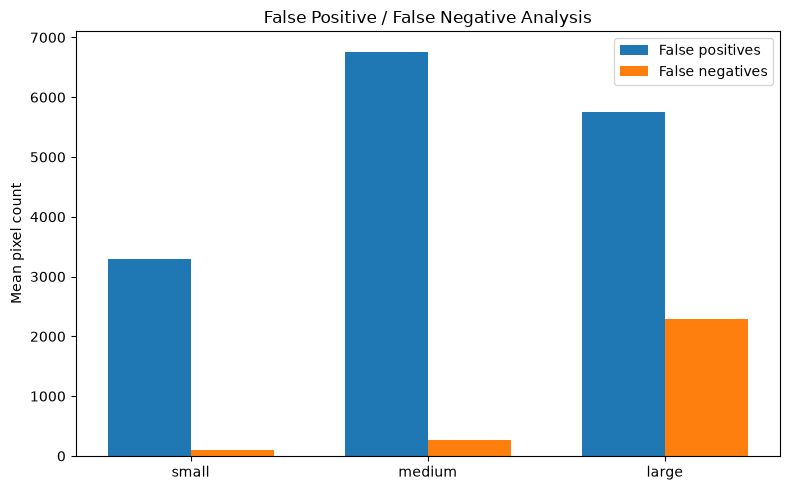

In [8]:

# ERROR ANALYSIS
per_image["fp_rate"]=per_image["fp_pixels"]/(SIZE*SIZE)
per_image["fn_rate"]=per_image["fn_pixels"]/(SIZE*SIZE)

error_summary=per_image.groupby("size_group").agg(
    images=("id","count"),
    mean_fp_pixels=("fp_pixels","mean"),
    mean_fn_pixels=("fn_pixels","mean"),
    mean_fp_rate=("fp_rate","mean"),
    mean_fn_rate=("fn_rate","mean")
).reindex(["small","medium","large"])

display(error_summary)
error_summary.to_csv(OUT/"error_summary.csv")

fig,ax=plt.subplots(figsize=(8,5))
x=np.arange(len(error_summary)); w=.35
ax.bar(x-w/2,error_summary["mean_fp_pixels"],w,label="False positives")
ax.bar(x+w/2,error_summary["mean_fn_pixels"],w,label="False negatives")
ax.set_xticks(x); ax.set_xticklabels(error_summary.index)
ax.set_ylabel("Mean pixel count")
ax.set_title("False Positive / False Negative Analysis")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"fp_fn_analysis.png",dpi=160,bbox_inches="tight")
plt.show()


In [9]:

# HARDEST / BEST CASES
hardest=per_image.nsmallest(10,"dice")
best=per_image.nlargest(10,"dice")

print("="*60)
print("HARDEST CASES")
print("="*60)
display(hardest[["id","size_group","defect_fraction","dice","iou","precision","recall"]])

print("="*60)
print("BEST CASES")
print("="*60)
display(best[["id","size_group","defect_fraction","dice","iou","precision","recall"]])

hardest.to_csv(OUT/"hardest_cases.csv",index=False)
best.to_csv(OUT/"best_cases.csv",index=False)


HARDEST CASES


,id,size_group,defect_fraction,dice,iou,precision,recall
65,150,small,0.006348,6.717270e-12,6.717270e-12,6.910372e-12,2.403846e-10
198,786,large,0.036102,2.163566e-11,2.163566e-11,4.432624e-11,4.226543e-11
125,378,small,0.004745,2.806624e-11,2.806624e-11,3.075031e-11,3.215434e-10
55,1246,medium,0.008163,9.337068e-11,9.337068e-11,1.865672e-10,1.869159e-10
127,385,small,0.002243,1.170960e-10,1.170960e-10,1.414427e-10,6.802721e-10
216,861,small,0.002960,1.336898e-10,1.336898e-10,1.805054e-10,5.154639e-10
225,892,small,0.001556,1.724138e-10,1.724138e-10,2.092050e-10,9.803922e-10
201,806,small,0.003632,1.865672e-10,1.865672e-10,3.355705e-10,4.201681e-10
218,865,small,0.001556,2.197802e-10,2.197802e-10,2.832861e-10,9.803922e-10
226,894,small,0.002853,2.500000e-10,2.500000e-10,4.694836e-10,5.347594e-10


BEST CASES


,id,size_group,defect_fraction,dice,iou,precision,recall
244,977,large,0.129028,0.936784,0.881085,0.956045,0.918283
248,981,large,0.123672,0.930563,0.870142,0.965760,0.897841
147,540,large,0.478775,0.928002,0.865676,0.993418,0.870670
146,538,large,0.479630,0.913295,0.840425,0.986562,0.850157
249,986,large,0.129318,0.912188,0.838552,0.956145,0.872094
243,974,large,0.070663,0.910117,0.835059,0.853202,0.975167
149,549,large,0.481339,0.909779,0.834490,0.979033,0.849675
247,980,large,0.131638,0.908801,0.832846,0.964965,0.858815
246,979,large,0.139145,0.901740,0.821063,0.957148,0.852396
18,1087,large,0.146820,0.899666,0.817631,0.863589,0.938890


In [10]:

# FINAL COMPARISON
comparison=pd.DataFrame([
    {
        "model":"Baseline",
        "Dice":0.206994,
        "IoU":0.143440,
        "Precision":0.313602,
        "Recall":0.539982
    },
    {
        "model":"Model 06 — Full loss",
        "Dice":0.353307,
        "IoU":0.252814,
        "Precision":0.325253,
        "Recall":0.682221
    },
    {
        "model":"Final — No boundary",
        "Dice":final_metrics["Dice"],
        "IoU":final_metrics["IoU"],
        "Precision":final_metrics["Precision"],
        "Recall":final_metrics["Recall"]
    }
])

display(comparison)
comparison.to_csv(OUT/"model_comparison.csv",index=False)

dice_gain=(final_metrics["Dice"]-0.206994)/0.206994*100
iou_gain=(final_metrics["IoU"]-0.143440)/0.143440*100

print(f"Dice improvement over baseline: {dice_gain:.2f}%")
print(f"IoU improvement over baseline: {iou_gain:.2f}%")


,model,Dice,IoU,Precision,Recall
0,Baseline,0.206994,0.143440,0.313602,0.539982
1,Model 06 — Full loss,0.353307,0.252814,0.325253,0.682221
2,Final — No boundary,0.375300,0.275828,0.348382,0.698829


Dice improvement over baseline: 81.31%
IoU improvement over baseline: 92.29%


In [11]:

# FINAL EVALUATION PACKAGE
summary={
    "model":"DefectVision MS-Residual U-Net",
    "loss":"Weighted BCE + Dice",
    "checkpoint_epoch":int(checkpoint["epoch"]),
    "threshold":THRESHOLD,
    "test_images":len(test_dataset),
    "validation_dice":float(checkpoint["val_dice"]),
    "validation_iou":float(checkpoint["val_iou"]),
    "test_dice":final_metrics["Dice"],
    "test_iou":final_metrics["IoU"],
    "test_precision":final_metrics["Precision"],
    "test_recall":final_metrics["Recall"]
}

pd.DataFrame([summary]).to_json(
    OUT/"final_evaluation_summary.json",
    orient="records",
    indent=2
)

print("="*60)
print("NOTEBOOK 09 COMPLETE")
print("="*60)
print("Results saved to:",OUT)


NOTEBOOK 09 COMPLETE
Results saved to: C:\Documents\DefectVision\results\final_evaluation
